# Importing neccesary libraries

In [25]:
from sklearn import  metrics
from sklearn.svm import SVC
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from torch.utils.data import TensorDataset,DataLoader
from torch import optim
import torch.nn as nn
import torch

# Load dataset

In [26]:
!gdown --id 1kFR51NiTY4mhb2j_7OqoDdj8cCiEcPHq
ds=pd.read_csv(r'ecg.csv',header=None)
data=ds.iloc[:,:-1].values
target=ds.iloc[:,-1].to_numpy()

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:138: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1kFR51NiTY4mhb2j_7OqoDdj8cCiEcPHq
To: /content/ecg.csv
100% 7.88M/7.88M [00:00<00:00, 189MB/s]


# Split data into train and test (70-30)

In [27]:
data_train,data_test,d_train,d_test= train_test_split(
     data,target,train_size=0.7,random_state=1)

# convert to tensor

In [28]:
data_train= torch.from_numpy(data_train).type(torch.float32)
d_train= torch.from_numpy(d_train).type(torch.float32)

data_test= torch.from_numpy(data_test).type(torch.float32)
d_test= torch.from_numpy(d_test).type(torch.float32)

# Bulid a data loader

In [29]:
ds= TensorDataset(data_train,d_train)
train_loader= DataLoader(ds,batch_size=32,shuffle=True)

# Design CNN Neural Network

In [30]:
class ConvNet(nn.Module):
     def __init__(self,num_kernel,n_hid1,n_hid2,n_out):
          super(ConvNet,self).__init__()
          self.conv1= nn.Conv1d(in_channels=1,out_channels=num_kernel,
                                kernel_size=5,padding=2)
          self.pool1=nn.MaxPool1d(kernel_size=4,stride=4)

          self.lin1= nn.Linear(in_features=num_kernel*35,out_features=n_hid1)
          self.lin2= nn.Linear(in_features=n_hid1,out_features=n_hid2)
          self.lin3= nn.Linear(in_features=n_hid2,out_features=n_out)

          self.tanh= nn.Tanh()
          self.sigmoid= nn.Sigmoid()

     def forward(self,data):
          out= self.conv1(data)
          out=self.tanh(out)

          out= self.pool1(out)

          out= out.flatten(start_dim=1)
          out= self.lin1(out)
          out=self.tanh(out)

          out= self.lin2(out)
          out=self.tanh(out)

          out= self.lin3(out)
          out= self.sigmoid(out)
          return out


# Create a Model using defined class

In [31]:
num_kernel= 20
n_hid1= 120
n_hid2= 80
n_out= 1
model= ConvNet(num_kernel,n_hid1,n_hid2,n_out)

# Define the optimizer

In [32]:
# optimizer= optim.SGD(params=model.parameters(),lr=0.001)
# optimizer= optim.SGD(params=model.parameters(),lr=0.001,momentum=0.2)
optimizer= optim.Adam(params=model.parameters(),lr=0.001,betas=(0.9,0.999),eps= 1e-8)

# Define cost function

In [33]:
criteria= nn.BCELoss()

# Train Neural Network

In [34]:
mse=[]
epoch=20
for iter in range(1,epoch):
     er=[]
     for xbatch,ybatch in train_loader:
          # farward pass
          xbatch= xbatch.unsqueeze(1)
          ypred= model(xbatch)
          # backward pass
          loss=  criteria(ypred.flatten(),ybatch)
          loss.backward() # triger gradient calculation
          optimizer.step()# update parameters(synaptic wieghts)
          optimizer.zero_grad() # clear gradients

          er.append(loss.detach())

     loss= torch.mean(torch.tensor(er))
     mse.append(loss)
     print(f'MSE({iter-1}): {mse[iter-1]}')

mse=torch.tensor(mse)

MSE(0): 0.09086368978023529
MSE(1): 0.0408022440969944
MSE(2): 0.029055338352918625
MSE(3): 0.02481379546225071
MSE(4): 0.023696597665548325
MSE(5): 0.02439548261463642
MSE(6): 0.01957283727824688
MSE(7): 0.021038440987467766
MSE(8): 0.01813214085996151
MSE(9): 0.016684455797076225
MSE(10): 0.01940741017460823
MSE(11): 0.014980103820562363
MSE(12): 0.015870729461312294
MSE(13): 0.01490200124680996
MSE(14): 0.01580057665705681
MSE(15): 0.012525604106485844
MSE(16): 0.013462419621646404
MSE(17): 0.013656878843903542
MSE(18): 0.01075542438775301


## Test trained Neural Network

In [35]:
with torch.no_grad():
     data_test= data_test.unsqueeze(1)
     ypred= model(data_test)
     ypred= torch.round(ypred)

# Calculate validation parameters

[[625   7]
 [  2 866]]
Accuracy:99.400%
Sensitivity:98.892%
Specificity:99.770%


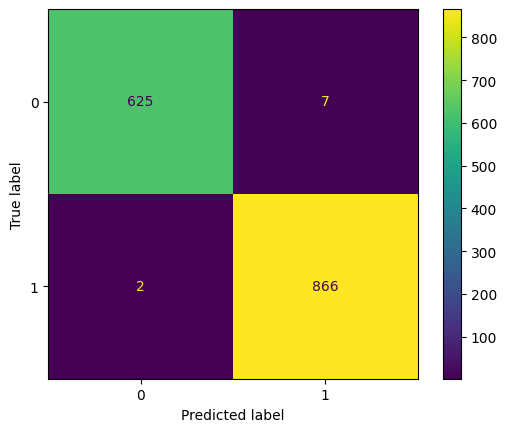

In [36]:
C= metrics.confusion_matrix(d_test.flatten(),ypred.flatten())
print(C)
accuracy= np.sum(np.diag(C))/ np.sum(C) *100
sensitivity= C[0,0]/ np.sum(C[0,:]) *100
specificity= C[1,1]/ np.sum(C[1,:]) *100
print(f'Accuracy:{accuracy:.3f}%')
print(f'Sensitivity:{sensitivity:.3f}%')
print(f'Specificity:{specificity:.3f}%')
disp= metrics.ConfusionMatrixDisplay(C)
disp.plot()
plt.show()